# Homework #3: Tornado Hazards & Further IN-CORE Analysis

Assignment due April 14, 2026 for AREN 8940: Infrastructure & Community Resilience

In [10]:
from pyincore import IncoreClient
from pyincore import HazardService, FragilityService, MappingSet, Dataset, DataService
from pyincore.models.fragilitycurveset import FragilityCurveSet
from pyincore.analyses.buildingdamage import BuildingDamage
from pyincore_viz.geoutil import GeoUtil as viz
from pyincore_viz.plotutil import PlotUtil as frag_plot

import json
import pandas as pd

## Task 3: Tornado Damage Analysis with IN-CORE

Simulate EF4 and EF5 tornado impacts on Joplin testbed using IN-CORE, comparing building damage, social and economic losses.

1. Create and simulate two scenarios: one EF4 and one EF5 tornado.

In [2]:
# Setup tools needed to run IN-CORE functions.
client = IncoreClient()
hzrdsvc = HazardService(client)

Connection successful to IN-CORE services. pyIncore version detected: 1.22.0


In [ ]:
# CREATING EF4 AND EF5 TORNADO HAZARD MODELS

# Create variables to store the tornado hazard input data.
ef4_model_metadata = {
    "name": "EF4 Model Tornado",
    "description": "Example EF4 tornado for Joplin, MO",
    "tornadoType": "model",
    "tornadoModel": "MeanWidthTornado",
    "tornadoParameters": {
        "efRating": "EF4",
        "startLatitude": "37.058",
        "startLongitude": "-94.483",
        "randomSeed": "1234",
        "endLatitude": [37.102],
        "endLongitude": [-94.550],
        "windSpeedMethod": "1",
        "numSimulations": "1"
    }
}

ef5_model_metadata = {
    "name": "EF5 Model Tornado",
    "description": "Example EF5 tornado for Joplin, MO",
    "tornadoType": "model",
    "tornadoModel": "MeanWidthTornado",
    "tornadoParameters": {
        "efRating": "EF5",
        "startLatitude": "37.058",
        "startLongitude": "-94.483",
        "randomSeed": "1234",
        "endLatitude": [37.102],
        "endLongitude": [-94.550],
        "windSpeedMethod": "1",
        "numSimulations": "1"
    }
}

# Turn metadata variables into json files.
ef4_tornado_json = json.dumps(ef4_model_metadata, indent = 4)
ef5_tornado_json = json.dumps(ef5_model_metadata, indent = 4)

# Use INCORE functions to create tornado models from json files.
ef4_model = hzrdsvc.create_tornado_scenario(ef4_tornado_json)
ef5_model = hzrdsvc.create_tornado_scenario(ef5_tornado_json)

In [ ]:
# Print information about new tornado models to determine ID numbers.
print(json.dumps(ef4_model, indent = 4, sort_keys = False))
print(json.dumps(ef5_model, indent = 4, sort_keys = False))

{
    "tornadoType": "model",
    "id": "69de7ca7a2ef3d7950890f46",
    "name": "EF4 Model Tornado",
    "description": "Example EF4 tornado for Joplin, MO",
    "creator": "jkehlers932",
    "owner": "jkehlers932",
    "threshold": null,
    "thresholdUnit": "mph",
    "spaces": [
        "jkehlers932"
    ],
    "date": "2026-04-14T17:43:02+0000",
    "tornadoModel": "MeanWidthTornado",
    "tornadoParameters": {
        "efRating": "EF4",
        "maxWindSpeed": 250.0,
        "startLatitude": 37.058,
        "startLongitude": -94.483,
        "randomSeed": 1234,
        "windSpeedMethod": 1,
        "numSimulations": 1,
        "endLatitude": [
            37.102
        ],
        "endLongitude": [
            -94.55
        ]
    },
    "tornadoWidth": [
        663.9219546174143
    ],
    "efBoxes": [
        {
            "efBoxWidths": [
                0.0008154678223728115,
                0.0013740483453900851,
                0.0019415900532685987,
                0.00246

Dataset already exists locally. Reading from local cached zip.
Unzipped folder found in the local cache. Reading from it...
Dataset already exists locally. Reading from local cached zip.
Unzipped folder found in the local cache. Reading from it...


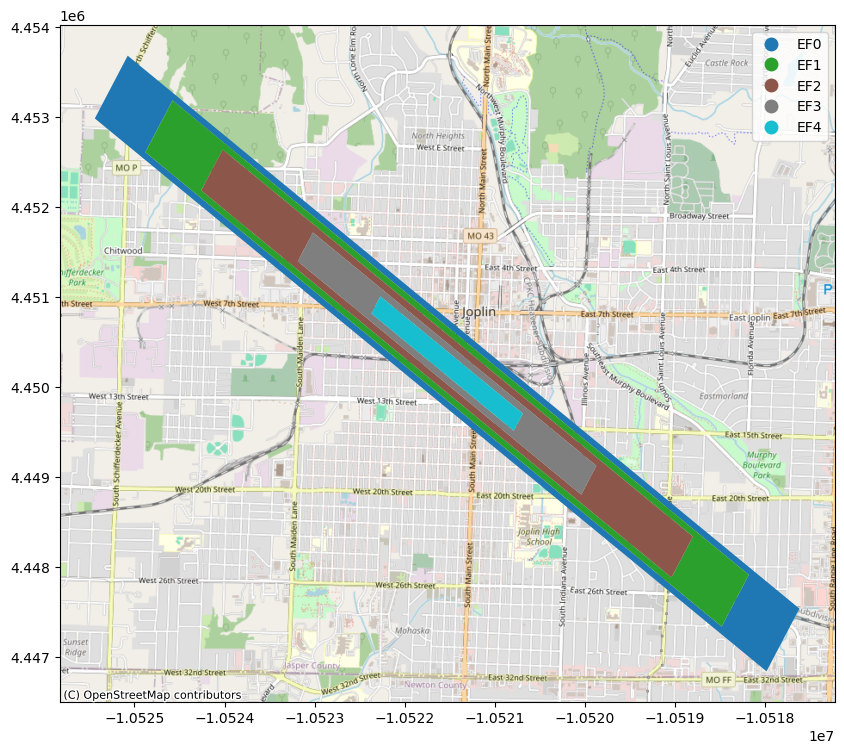

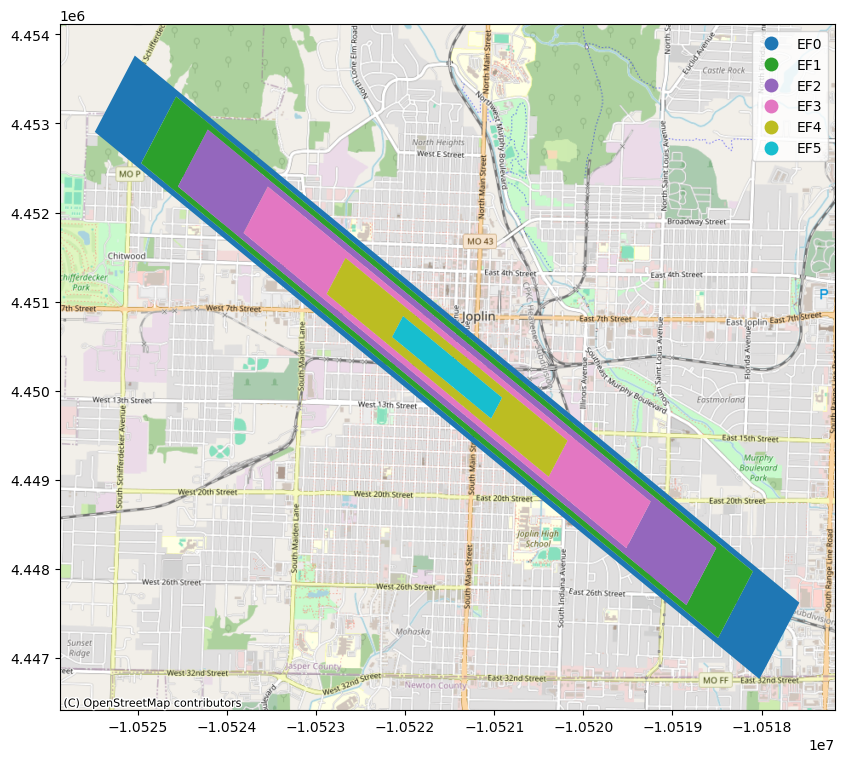

In [4]:
# Define tornado ID variables.
ef4_ID = "69de7ca7a2ef3d7950890f46"
ef5_ID = "69de7ca90d32537251a7dd8b"

# Plot the tornadoes with map showing underneath.
viz.plot_tornado(ef4_ID, client, basemap = True)
viz.plot_tornado(ef5_ID, client, basemap = True)

2. Analyze and compare the outcomes of both scenarios. Identify which areas and building types were most affected.

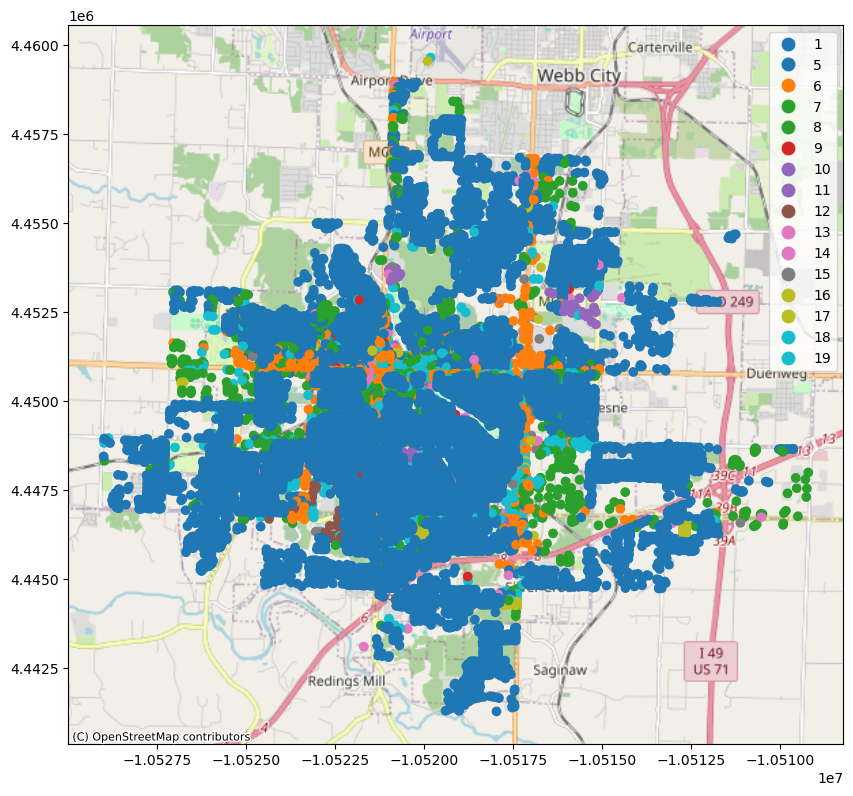

In [6]:
# Import building dataset for Joplin.
bldg_id_num = "5dbc8478b9219c06dd242c0d"
bldg_dataset = Dataset.from_data_service(bldg_id_num, DataService(client))
viz.plot_map(bldg_dataset, column = 'archetype', category = 'True')

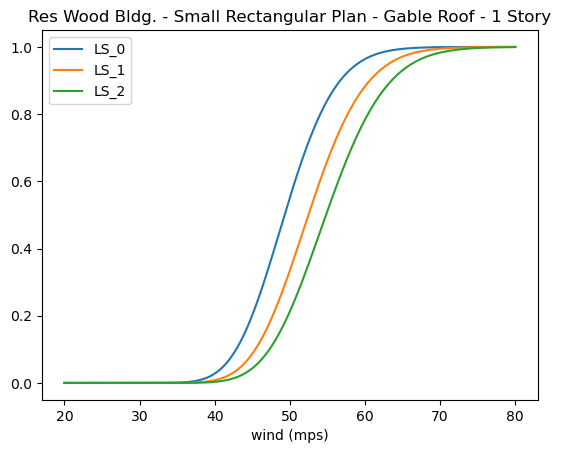

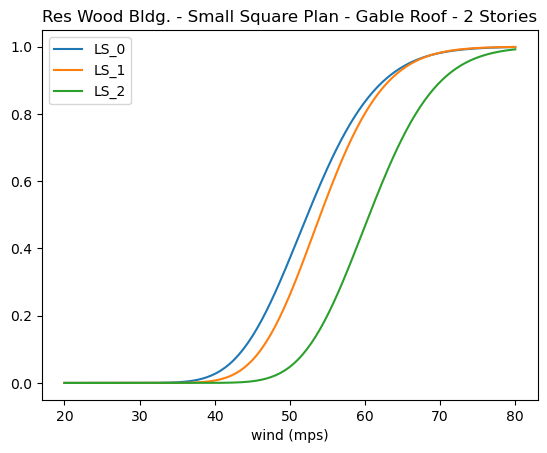

In [9]:
# Import fragility curves for the 19 building archetypes
fragility_svc = FragilityService(client)
frag_mapping_id = "5d8942dfb9219c068ea795ea"
frag_mapping_set = MappingSet(fragility_svc.get_mapping(frag_mapping_id))

# Plot the first couple curves to check it worked.
for mapping in frag_mapping_set.mappings[:2]:
    fragility_id = mapping.entry['Non-Retrofit Fragility ID Code']
    fragility_set = FragilityCurveSet(fragility_svc.get_dfr3_set(fragility_id))
    plt = frag_plot.get_fragility_plot(fragility_set, start=20, end=80)
    plt.show()

In [11]:
# Connect the fragility curves to the building data??
mapping_id = "5d8942dfb9219c068ea795ea"
fragility_service = FragilityService(client)
mapping_set = MappingSet(fragility_service.get_mapping(mapping_id))

# Run building damage model from hazard and existing building datasets.
bldg_dmg = BuildingDamage(client)
bldg_inventory = bldg_dmg.load_remote_input_dataset("buildings", bldg_id_num)
bldg_dmg.set_input_dataset("dfr3_mapping_set", mapping_set)


Dataset already exists locally. Reading from local cached zip.
Unzipped folder found in the local cache. Reading from it...


C:\Users\jkehl\AppData\Local\Temp\ipykernel_6196\2616393430.py:7: DeprecationWarning: Call to deprecated class BuildingDamage. (This class will be deprecated soon. Use BuildingStructuralDamage instead.) -- Deprecated since version 1.19.0.
  bldg_dmg = BuildingDamage(client)


True

In [13]:
# EF4 TORNADO MODEL ON JOPLIN TESTBED

# Set initial parameters for EF4 model.
bldg_dmg.set_parameter("result_name", "joplin_testbed_ef4_model")
bldg_dmg.set_parameter("hazard_type", "tornado")
bldg_dmg.set_parameter("hazard_id", ef4_ID)
bldg_dmg.set_parameter("num_cpu", 4)

# Run the analysis for EF4 model.
bldg_dmg.run_analysis()
ef4_bldg_dmg_result = bldg_dmg.get_output_dataset('ds_result')

# Convert dataset to dataframe and display output data.
df_ef4_bldg_dmg = ef4_bldg_dmg_result.get_dataframe_from_csv()
df_ef4_bldg_dmg.head()

,guid,LS_0,LS_1,LS_2,DS_0,DS_1,DS_2,DS_3,haz_expose
0,b497b88f-a4ba-48b1-8438-5cfc68147cfc,0.0,0.0,0.0,1.0,0.0,0.0,0.0,no
1,6eadcc3e-7bb5-463a-aca8-f1d16f8ac7cc,0.0,0.0,0.0,1.0,0.0,0.0,0.0,no
2,758fb3de-108a-4e04-895e-fdc4b8627876,0.0,0.0,0.0,1.0,0.0,0.0,0.0,no
3,7b706697-bf9b-4883-90f6-862d67a8e64b,0.0,0.0,0.0,1.0,0.0,0.0,0.0,no
4,19c91f9b-f679-4263-b7a3-e76fd859c4b1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,no


In [14]:
# EF5 TORNADO MODEL ON JOPLIN TESTBED

# Set initial parameters for EF4 model.
bldg_dmg.set_parameter("result_name", "joplin_testbed_ef5_model")
bldg_dmg.set_parameter("hazard_type", "tornado")
bldg_dmg.set_parameter("hazard_id", ef5_ID)
bldg_dmg.set_parameter("num_cpu", 4)

# Run the analysis for EF4 model.
bldg_dmg.run_analysis()
ef5_bldg_dmg_result = bldg_dmg.get_output_dataset('ds_result')

# Convert dataset to dataframe and display output data.
df_ef5_bldg_dmg = ef4_bldg_dmg_result.get_dataframe_from_csv()
df_ef5_bldg_dmg.head()

,guid,LS_0,LS_1,LS_2,DS_0,DS_1,DS_2,DS_3,haz_expose
0,b497b88f-a4ba-48b1-8438-5cfc68147cfc,0.0,0.0,0.0,1.0,0.0,0.0,0.0,no
1,6eadcc3e-7bb5-463a-aca8-f1d16f8ac7cc,0.0,0.0,0.0,1.0,0.0,0.0,0.0,no
2,758fb3de-108a-4e04-895e-fdc4b8627876,0.0,0.0,0.0,1.0,0.0,0.0,0.0,no
3,7b706697-bf9b-4883-90f6-862d67a8e64b,0.0,0.0,0.0,1.0,0.0,0.0,0.0,no
4,19c91f9b-f679-4263-b7a3-e76fd859c4b1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,no


3. Visualize the results with graphs and maps, and compile a report discussing your findings and suggesting mitigation strategies.

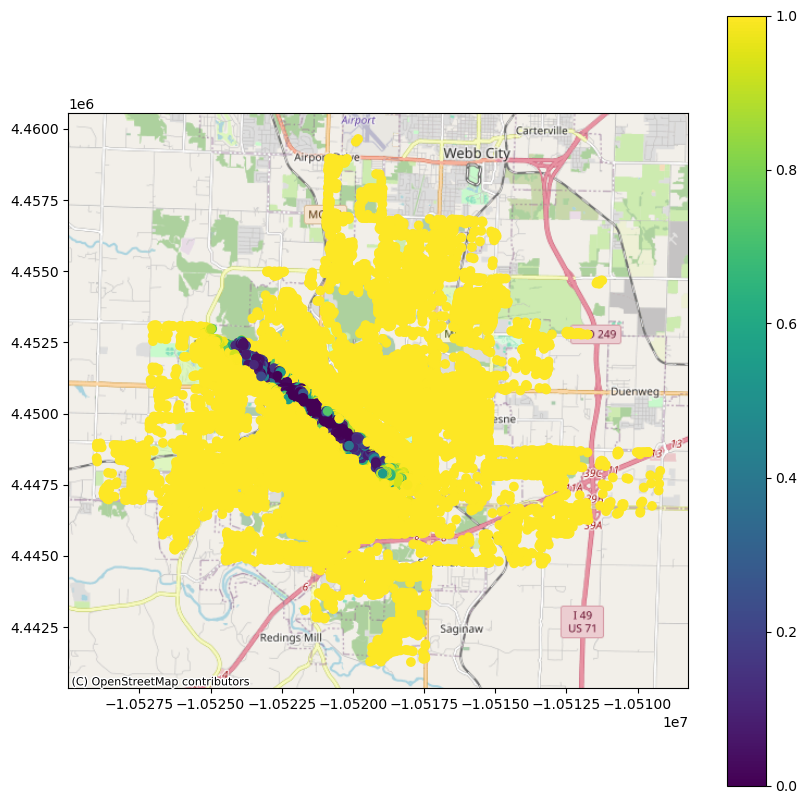

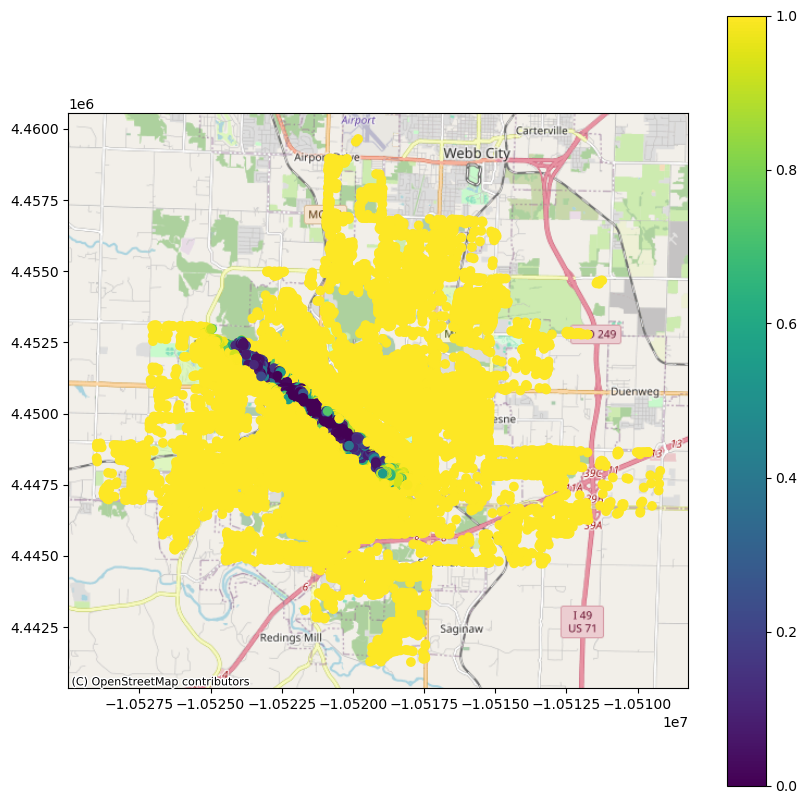

In [ ]:
# Get geo data from building dataset adn add it to damage dataframe.
bldg_gdf = bldg_dataset.get_dataframe_from_shapefile()
ef4_gdfANDdmg_df = bldg_gdf.merge(df_ef4_bldg_dmg, on = 'guid')
ef5_gdfANDdmg_df = bldg_gdf.merge(df_ef5_bldg_dmg, on = 'guid')

# Plot based on damage state 0 -> yellow buildings with value of 1 were unaffected.
viz.plot_gdf_map(ef4_gdfANDdmg_df, column = 'DS_0')
viz.plot_gdf_map(ef5_gdfANDdmg_df, column = 'DS_0')

**NOTE**: Findings and mitigation strategy suggestions are compiled in report for this assignment. Code below shows how graphs were generated.

## Task 4: Earthquake Impacts on Emergency Services

Building upon our findings from Task 3 of Homework 2, this task focuses on the visualization and further analysis of the estimated damage impacts of a 6.7 magnitude earthquake on the police and fire stations in Shelby County, TN. You are expected to extend your previous work by incorporating damage prediction models and visualizing the potential damage.

1. Revisit the building inventroy dataset ('shelby-police-fire-station.csv') used in Task 3 of Homework 2.

In [ ]:
# Import the CSV file as a pandas dataframe here.

2. Apply a Ground Motion Prediction Equation (GMPE) to simulate a 6.7 magnitude earthquake in an epicenter of choice within Shelby County, TN.

3. Using the IN-CORE, estimate the damage to each building based on the simulated earthquake.

4. Visualize the damage assessments using appropriate Python libraries (e.g., Matplotlib, Seaborn) or GIS tools (e.g., QGIS, ArcGIS) integrated with your Jupyter notebook.